# Notebook 05 — Rainfall and Soil Factors

## Objective

This notebook prepares rainfall and soil-related flood-conditioning factors
for the Gomti River–influenced Lucknow study area.

The notebook uses externally sourced rainfall and soil datasets and converts
them into spatially consistent datasets suitable for subsequent flood
susceptibility modelling.

The main components are:

1. CHIRPS rainfall data
2. SoilGrids soil-property data

The processing workflow includes data acquisition, quality assessment,
study-area clipping, spatial verification, and preparation of final
conditioning-factor rasters.

The implemented temporal framework currently uses the LULC observation years:

- 2003
- 2014
- 2025

The rainfall and soil factor design will be finalized after evaluating
dataset availability, spatial resolution, temporal coverage, and scientific
suitability.

## 5.1 Notebook Setup

This step initializes the working environment for Notebook 05 and establishes
the project root directory.

Notebook 05 is developed independently from the previous notebooks, so the
required paths and environment variables are initialized explicitly rather
than relying on variables remaining in memory from Notebook 04.

The project root is used as the base directory for accessing raw datasets,
processed datasets, notebooks, and final outputs throughout the rainfall and
soil preprocessing workflow.

In [1]:
# ============================================================
# Step 05.1 — Notebook Setup
# ============================================================

from pathlib import Path

print("=" * 70)
print("NOTEBOOK 05 — RAINFALL AND SOIL FACTORS")
print("=" * 70)

# ------------------------------------------------------------
# Project root
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd().parent

print("Project root:")
print(PROJECT_ROOT)

NOTEBOOK 05 — RAINFALL AND SOIL FACTORS
Project root:
d:\Projects\GeoAI-Flood-Susceptibility


## 5.2 Project Directory Structure

This step defines the directory paths used throughout Notebook 05.

Raw rainfall data downloaded from CHIRPS are retained in the `data/raw`
directory and organized by observation year. Raw soil data are also stored
separately so that the original downloaded datasets remain unchanged.

Processed rainfall and soil datasets generated during this notebook are
stored under the Notebook 05 processing directory.

Final tables and figures are stored in the project's existing output
directories.

In [2]:
# ============================================================
# Step 05.2 — Define Project Directory Paths
# ============================================================

# ------------------------------------------------------------
# Raw data directories
# ------------------------------------------------------------

RAW_DIR = PROJECT_ROOT / "data" / "raw"

RAINFALL_RAW_DIR = (
    RAW_DIR / "rainfall"
)

SOIL_RAW_DIR = (
    RAW_DIR / "soil"
)

# ------------------------------------------------------------
# Processed data directory for Notebook 05
# ------------------------------------------------------------

PROCESSED_NB05_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_05"
)

RAINFALL_PROCESSED_DIR = (
    PROCESSED_NB05_DIR / "rainfall"
)

SOIL_PROCESSED_DIR = (
    PROCESSED_NB05_DIR / "soil"
)

# ------------------------------------------------------------
# Output directories
# ------------------------------------------------------------

OUTPUTS_DIR = (
    PROJECT_ROOT / "outputs"
)

TABLES_DIR = (
    OUTPUTS_DIR / "tables"
)

FIGURES_DIR = (
    OUTPUTS_DIR / "figures"
)

# ------------------------------------------------------------
# Display paths
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — PROJECT DIRECTORIES")
print("=" * 70)

print("\nRaw rainfall:")
print(RAINFALL_RAW_DIR)

print("\nRaw soil:")
print(SOIL_RAW_DIR)

print("\nProcessed rainfall:")
print(RAINFALL_PROCESSED_DIR)

print("\nProcessed soil:")
print(SOIL_PROCESSED_DIR)

print("\nTables:")
print(TABLES_DIR)

print("\nFigures:")
print(FIGURES_DIR)

NOTEBOOK 05 — PROJECT DIRECTORIES

Raw rainfall:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\rainfall

Raw soil:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\soil

Processed rainfall:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_05\rainfall

Processed soil:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_05\soil

Tables:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\tables

Figures:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures


## 5.3 Required Python Libraries

The rainfall and soil preprocessing workflow requires libraries for raster
processing, vector-data handling, numerical computation, tabular analysis,
and visualization.

The main libraries used in this notebook are:

- **Rasterio** — reading, writing, and processing raster datasets.
- **GeoPandas** — loading and handling the study-area vector geometry.
- **NumPy** — numerical and array-based calculations.
- **Pandas** — organizing rainfall and soil statistics in tabular form.
- **Matplotlib** — quality-control plots and final visualizations.

Only the libraries required for the current workflow are loaded.

In [3]:
# ============================================================
# Step 05.3 — Load Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
import matplotlib.pyplot as plt

print("=" * 70)
print("NOTEBOOK 05 — LIBRARY CHECK")
print("=" * 70)

print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
print(f"GeoPandas   : {gpd.__version__}")
print(f"Rasterio    : {rasterio.__version__}")
print(f"Matplotlib  : {plt.matplotlib.__version__}")

print("\n✓ All required libraries imported successfully.")

NOTEBOOK 05 — LIBRARY CHECK
NumPy       : 2.5.2
Pandas      : 3.0.5
GeoPandas   : 1.1.4
Rasterio    : 1.5.1
Matplotlib  : 3.11.1

✓ All required libraries imported successfully.


## 5.4 Load the Study-Area Boundary

The study area defined in Notebook 01 is reused in Notebook 05 to ensure
that rainfall and soil datasets are processed over exactly the same spatial
domain.

The study-area boundary is stored as a GeoPackage:

`data/processed/notebook_01/Lucknow_Search_Area_20km.gpkg`

The layer is loaded explicitly in this notebook and its CRS, geometry count,
and spatial extent are verified before being used for subsequent processing.

In [4]:
# ============================================================
# Step 05.4 — Load Study Area
# ============================================================

study_area_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "notebook_01"
    / "Lucknow_Search_Area_20km.gpkg"
)

# ------------------------------------------------------------
# Check that the file exists
# ------------------------------------------------------------

if not study_area_path.exists():
    raise FileNotFoundError(
        f"Study-area file not found:\n{study_area_path}"
    )

# ------------------------------------------------------------
# Load study area
# ------------------------------------------------------------

study_area_gdf = gpd.read_file(
    study_area_path
)

# ------------------------------------------------------------
# Basic verification
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — STUDY AREA")
print("=" * 70)

print("\nFile:")
print(study_area_path)

print("\nCRS:")
print(study_area_gdf.crs)

print("\nNumber of features:")
print(len(study_area_gdf))

print("\nBounds:")
print(study_area_gdf.total_bounds)

print("\nGeometry types:")
print(study_area_gdf.geometry.geom_type.value_counts())

print("\n✓ Study area loaded successfully.")

NOTEBOOK 05 — STUDY AREA

File:
d:\Projects\GeoAI-Flood-Susceptibility\data\processed\notebook_01\Lucknow_Search_Area_20km.gpkg

CRS:
None

Number of features:
1

Bounds:
[ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

Geometry types:
MultiPolygon    1
Name: count, dtype: int64

✓ Study area loaded successfully.


## 5.5 Study-Area CRS Verification

The loaded study-area GeoPackage does not contain CRS metadata. The geometry
coordinates are consistent with the projected coordinate system previously
established for the study area.

The study uses **WGS 84 / UTM Zone 44N (EPSG:32644)** for the projected
study-area analysis.

The missing CRS metadata is therefore explicitly assigned to the study-area
GeoDataFrame without changing the underlying coordinate values.

The study-area CRS will subsequently be transformed to the coordinate
reference system required by external rainfall and soil datasets when
performing spatial subsetting and reprojection.

In [5]:
# ============================================================
# Step 05.5 — Verify and Assign Study-Area CRS
# ============================================================

EXPECTED_CRS = "EPSG:32644"

print("=" * 70)
print("NOTEBOOK 05 — STUDY AREA CRS CHECK")
print("=" * 70)

print("\nCRS read from file:")
print(study_area_gdf.crs)

# ------------------------------------------------------------
# Assign the established study CRS
# ------------------------------------------------------------

if study_area_gdf.crs is None:

    study_area_gdf = study_area_gdf.set_crs(
        EXPECTED_CRS
    )

    print(
        f"\n✓ CRS metadata was missing."
        f"\n✓ Assigned: {EXPECTED_CRS}"
    )

else:

    if study_area_gdf.crs.to_string() != EXPECTED_CRS:

        raise ValueError(
            f"Unexpected study-area CRS: "
            f"{study_area_gdf.crs}. "
            f"Expected {EXPECTED_CRS}."
        )

    print(
        f"\n✓ Study-area CRS already matches "
        f"{EXPECTED_CRS}."
    )

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\nFinal study-area CRS:")
print(study_area_gdf.crs)

print("\nBounds:")
print(study_area_gdf.total_bounds)

print("\n✓ Study-area CRS is ready for Notebook 05.")

NOTEBOOK 05 — STUDY AREA CRS CHECK

CRS read from file:
None

✓ CRS metadata was missing.
✓ Assigned: EPSG:32644

Final study-area CRS:
EPSG:32644

Bounds:
[ 463358.57983883 2938218.33094633  526062.35561871 2998994.24737365]

✓ Study-area CRS is ready for Notebook 05.


## 5.6 CHIRPS Raw Dataset Verification

The monthly CHIRPS rainfall files required for the monsoon rainfall
component are stored in the project raw-data directory.

Four monthly rainfall rasters (June–September) are used for each observation
year: 2003, 2014, and 2025.

The original compressed `.tif.gz` files are retained unchanged in the raw
data directory. Before processing, their presence and filenames are verified
to ensure that the expected temporal coverage is available.

In [6]:
# ============================================================
# Step 05.6 — Verify CHIRPS Raw Files
# ============================================================

chirps_years = [2003, 2014, 2025]
chirps_months = [6, 7, 8, 9]

print("=" * 70)
print("NOTEBOOK 05 — CHIRPS RAW DATA VERIFICATION")
print("=" * 70)

missing_files = []

for year in chirps_years:

    year_dir = RAINFALL_RAW_DIR / str(year)

    print(f"\n{year}")
    print("-" * 50)

    for month in chirps_months:

        filename = (
            f"chirps-v2.0.{year}.{month:02d}.tif.gz"
        )

        path = year_dir / filename

        if path.exists():

            size_mb = path.stat().st_size / (1024 ** 2)

            print(
                f"✓ {filename:<35} "
                f"{size_mb:.2f} MB"
            )

        else:

            print(
                f"✗ MISSING: {filename}"
            )

            missing_files.append(path)

# ------------------------------------------------------------
# Final result
# ------------------------------------------------------------

print("\n" + "=" * 70)

if not missing_files:

    print(
        "✓ ALL 12 EXPECTED CHIRPS FILES ARE PRESENT"
    )

else:

    print(
        f"✗ {len(missing_files)} CHIRPS FILE(S) ARE MISSING"
    )

    print("\nMissing files:")

    for path in missing_files:
        print(path)

print("=" * 70)

NOTEBOOK 05 — CHIRPS RAW DATA VERIFICATION

2003
--------------------------------------------------
✓ chirps-v2.0.2003.06.tif.gz          13.92 MB
✓ chirps-v2.0.2003.07.tif.gz          13.98 MB
✓ chirps-v2.0.2003.08.tif.gz          13.97 MB
✓ chirps-v2.0.2003.09.tif.gz          13.94 MB

2014
--------------------------------------------------
✓ chirps-v2.0.2014.06.tif.gz          13.92 MB
✓ chirps-v2.0.2014.07.tif.gz          13.96 MB
✓ chirps-v2.0.2014.08.tif.gz          13.91 MB
✓ chirps-v2.0.2014.09.tif.gz          13.89 MB

2025
--------------------------------------------------
✓ chirps-v2.0.2025.06.tif.gz          13.96 MB
✓ chirps-v2.0.2025.07.tif.gz          13.98 MB
✓ chirps-v2.0.2025.08.tif.gz          13.97 MB
✓ chirps-v2.0.2025.09.tif.gz          13.94 MB

✓ ALL 12 EXPECTED CHIRPS FILES ARE PRESENT


## 5.7 CHIRPS Raster Metadata Inspection

Before processing the rainfall dataset, the spatial and numerical properties
of a representative CHIRPS raster are inspected.

The inspection verifies the raster dimensions, coordinate reference system,
spatial resolution, geographic extent, data type, NoData value, and rainfall
value range.

This provides a quality-control checkpoint before the CHIRPS rasters are
decompressed, clipped to the study area, and aggregated into the selected
rainfall factor.

In [7]:
# ============================================================
# Step 05.7 — Inspect a CHIRPS Raster
# ============================================================

import gzip
import tempfile

# ------------------------------------------------------------
# Select one representative raw CHIRPS file
# ------------------------------------------------------------

sample_chirps_path = (
    RAINFALL_RAW_DIR
    / "2003"
    / "chirps-v2.0.2003.06.tif.gz"
)

if not sample_chirps_path.exists():
    raise FileNotFoundError(
        f"CHIRPS sample file not found:\n{sample_chirps_path}"
    )

# ------------------------------------------------------------
# Temporarily decompress the file for inspection
# ------------------------------------------------------------

with tempfile.NamedTemporaryFile(
    suffix=".tif",
    delete=False
) as temp_file:

    temp_tif_path = Path(temp_file.name)

with gzip.open(
    sample_chirps_path,
    "rb"
) as gz_file:

    with open(
        temp_tif_path,
        "wb"
    ) as tif_file:

        tif_file.write(
            gz_file.read()
        )

# ------------------------------------------------------------
# Inspect raster metadata
# ------------------------------------------------------------

with rasterio.open(temp_tif_path) as src:

    data = src.read(1)

    print("=" * 70)
    print("CHIRPS RASTER METADATA — SAMPLE FILE")
    print("=" * 70)

    print("\nFile:")
    print(sample_chirps_path)

    print("\nRaster shape:")
    print(src.shape)

    print("\nNumber of bands:")
    print(src.count)

    print("\nCRS:")
    print(src.crs)

    print("\nResolution:")
    print(src.res)

    print("\nBounds:")
    print(src.bounds)

    print("\nData type:")
    print(src.dtypes[0])

    print("\nNoData value:")
    print(src.nodata)

    print("\nMinimum rainfall value:")
    print(np.nanmin(data))

    print("\nMaximum rainfall value:")
    print(np.nanmax(data))

# ------------------------------------------------------------
# Remove temporary decompressed file
# ------------------------------------------------------------

temp_tif_path.unlink()

print("\n✓ Temporary inspection file removed.")
print("✓ Raw .tif.gz file was not modified.")

CHIRPS RASTER METADATA — SAMPLE FILE

File:
d:\Projects\GeoAI-Flood-Susceptibility\data\raw\rainfall\2003\chirps-v2.0.2003.06.tif.gz

Raster shape:
(2000, 7200)

Number of bands:
1

CRS:
EPSG:4326

Resolution:
(0.05000000074505806, 0.05000000074505806)

Bounds:
BoundingBox(left=-180.0, bottom=-50.00000149011612, right=180.00000536441803, top=50.0)

Data type:
float32

NoData value:
None

Minimum rainfall value:
-9999.0

Maximum rainfall value:
1552.4633

✓ Temporary inspection file removed.
✓ Raw .tif.gz file was not modified.


In [8]:
# ============================================================
# Step 05.7 — Verify NoData and Dataset Metadata
# ============================================================

with tempfile.NamedTemporaryFile(
    suffix=".tif",
    delete=False
) as temp_file:

    temp_tif_path = Path(temp_file.name)

with gzip.open(
    sample_chirps_path,
    "rb"
) as gz_file:

    with open(
        temp_tif_path,
        "wb"
    ) as tif_file:

        tif_file.write(
            gz_file.read()
        )

with rasterio.open(temp_tif_path) as src:

    print("=" * 70)
    print("CHIRPS NODATA / METADATA CHECK")
    print("=" * 70)

    print("\nNoData value:")
    print(src.nodata)

    print("\nRaster tags:")
    print(src.tags())

    print("\nBand 1 tags:")
    print(src.tags(1))

temp_tif_path.unlink()

print("\n✓ Metadata check completed.")

CHIRPS NODATA / METADATA CHECK

NoData value:
None

Raster tags:
{'TIFFTAG_DOCUMENTNAME': '/home/CHIRPS/monthly/v2.0/chirps-v2.0.2003.06.tif', 'TIFFTAG_IMAGEDESCRIPTION': 'IDL TIFF file', 'TIFFTAG_SOFTWARE': 'IDL 8.3, Exelis Visual Information Solutions, Inc.', 'TIFFTAG_DATETIME': '2015:01:30 05:09:45', 'TIFFTAG_XRESOLUTION': '100', 'TIFFTAG_YRESOLUTION': '100', 'TIFFTAG_RESOLUTIONUNIT': '2 (pixels/inch)', 'AREA_OR_POINT': 'Area'}

Band 1 tags:
{}

✓ Metadata check completed.


## 5.8 Decompression of CHIRPS Monthly Rasters

The downloaded CHIRPS monthly rainfall files are provided as compressed
GeoTIFF archives (`.tif.gz`).

The original compressed files are retained unchanged in the raw-data
directory to preserve the original downloaded dataset.

For raster processing, the compressed files are decompressed into the
Notebook 05 processed-data directory while preserving the year and month
organization.

No spatial transformation or rainfall calculation is performed during this
step. The operation only converts the compressed archives into standard
GeoTIFF files suitable for subsequent processing.

In [9]:
# ============================================================
# Step 05.8 — Decompress CHIRPS Monthly Rasters
# ============================================================

import gzip
import shutil

# ------------------------------------------------------------
# Create processed rainfall directories
# ------------------------------------------------------------

for year in chirps_years:

    year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    year_dir.mkdir(
        parents=True,
        exist_ok=True
    )

# ------------------------------------------------------------
# Decompress each CHIRPS file
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — CHIRPS DECOMPRESSION")
print("=" * 70)

decompressed_files = []

for year in chirps_years:

    raw_year_dir = (
        RAINFALL_RAW_DIR
        / str(year)
    )

    processed_year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    print(f"\n{year}")
    print("-" * 50)

    for month in chirps_months:

        filename = (
            f"chirps-v2.0.{year}.{month:02d}.tif.gz"
        )

        input_path = (
            raw_year_dir / filename
        )

        output_filename = filename[:-3]  # remove ".gz"

        output_path = (
            processed_year_dir
            / output_filename
        )

        if not input_path.exists():

            raise FileNotFoundError(
                f"Missing raw CHIRPS file:\n{input_path}"
            )

        # ----------------------------------------------------
        # Skip decompression if output already exists
        # ----------------------------------------------------

        if output_path.exists():

            print(
                f"✓ Already exists: "
                f"{output_filename}"
            )

        else:

            with gzip.open(
                input_path,
                "rb"
            ) as source:

                with open(
                    output_path,
                    "wb"
                ) as destination:

                    shutil.copyfileobj(
                        source,
                        destination
                    )

            print(
                f"✓ Decompressed: "
                f"{output_filename}"
            )

        decompressed_files.append(
            output_path
        )

# ------------------------------------------------------------
# Final verification
# ------------------------------------------------------------

print("\n" + "=" * 70)

missing_processed = [
    path
    for path in decompressed_files
    if not path.exists()
]

if not missing_processed:

    print(
        "✓ ALL 12 CHIRPS RASTERS DECOMPRESSED SUCCESSFULLY"
    )

else:

    print(
        f"✗ {len(missing_processed)} "
        f"PROCESSED FILE(S) ARE MISSING"
    )

print("=" * 70)

NOTEBOOK 05 — CHIRPS DECOMPRESSION

2003
--------------------------------------------------
✓ Decompressed: chirps-v2.0.2003.06.tif
✓ Decompressed: chirps-v2.0.2003.07.tif
✓ Decompressed: chirps-v2.0.2003.08.tif
✓ Decompressed: chirps-v2.0.2003.09.tif

2014
--------------------------------------------------
✓ Decompressed: chirps-v2.0.2014.06.tif
✓ Decompressed: chirps-v2.0.2014.07.tif
✓ Decompressed: chirps-v2.0.2014.08.tif
✓ Decompressed: chirps-v2.0.2014.09.tif

2025
--------------------------------------------------
✓ Decompressed: chirps-v2.0.2025.06.tif
✓ Decompressed: chirps-v2.0.2025.07.tif
✓ Decompressed: chirps-v2.0.2025.08.tif
✓ Decompressed: chirps-v2.0.2025.09.tif

✓ ALL 12 CHIRPS RASTERS DECOMPRESSED SUCCESSFULLY


## 5.9 Verification of Decompressed CHIRPS Rasters

The decompressed CHIRPS GeoTIFF files are verified before further processing.

The verification confirms that decompression preserved the spatial reference,
resolution, raster dimensions, band structure, data type, and geographic
extent of the original CHIRPS product.

All twelve monthly rasters (June–September for 2003, 2014, and 2025) are
expected to retain the same global spatial grid.

In [10]:
# ============================================================
# Step 05.9 — Verify Decompressed CHIRPS Rasters
# ============================================================

print("=" * 70)
print("NOTEBOOK 05 — DECOMPRESSED CHIRPS VERIFICATION")
print("=" * 70)

processed_chirps_paths = {}

for year in chirps_years:

    processed_chirps_paths[year] = {}

    year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    print(f"\n{year}")
    print("-" * 70)

    for month in chirps_months:

        filename = (
            f"chirps-v2.0.{year}.{month:02d}.tif"
        )

        path = year_dir / filename

        if not path.exists():

            raise FileNotFoundError(
                f"Processed CHIRPS file not found:\n{path}"
            )

        processed_chirps_paths[year][month] = path

        with rasterio.open(path) as src:

            print(
                f"{filename} | "
                f"shape={src.shape} | "
                f"CRS={src.crs} | "
                f"resolution={src.res} | "
                f"bands={src.count} | "
                f"dtype={src.dtypes[0]}"
            )

print("\n" + "=" * 70)
print("✓ ALL 12 DECOMPRESSED CHIRPS RASTERS VERIFIED")
print("=" * 70)

NOTEBOOK 05 — DECOMPRESSED CHIRPS VERIFICATION

2003
----------------------------------------------------------------------
chirps-v2.0.2003.06.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2003.07.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2003.08.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2003.09.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32

2014
----------------------------------------------------------------------
chirps-v2.0.2014.06.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.05000000074505806, 0.05000000074505806) | bands=1 | dtype=float32
chirps-v2.0.2014.07.tif | shape=(2000, 7200) | CRS=EPSG:4326 | resolution=(0.0500000

## 5.10 Spatial Clipping of CHIRPS Rainfall

The global CHIRPS monthly rasters are spatially subsetted to the defined
Gomti River–influenced Lucknow study area.

Because the CHIRPS rasters use geographic coordinates (EPSG:4326), the
study-area geometry, originally defined in EPSG:32644, is transformed to
EPSG:4326 before clipping.

Four monthly rainfall rasters (June–September) are clipped for each
observation year: 2003, 2014, and 2025.

The clipped rasters retain the CHIRPS spatial reference and rainfall values
while substantially reducing the spatial extent of the data used in
subsequent processing.

The original raw and decompressed CHIRPS datasets are preserved unchanged.

In [11]:
# ============================================================
# Step 05.10 — Clip CHIRPS Rasters to Study Area
# ============================================================

from rasterio.mask import mask

# ------------------------------------------------------------
# Transform study area to CHIRPS CRS
# ------------------------------------------------------------

chirps_crs = "EPSG:4326"

study_area_chirps = (
    study_area_gdf
    .to_crs(chirps_crs)
)

print("=" * 70)
print("NOTEBOOK 05 — CHIRPS STUDY-AREA CLIPPING")
print("=" * 70)

print("\nOriginal study-area CRS:")
print(study_area_gdf.crs)

print("\nCHIRPS CRS:")
print(chirps_crs)

print("\nTransformed study-area CRS:")
print(study_area_chirps.crs)

print("\nStudy-area bounds in CHIRPS CRS:")
print(study_area_chirps.total_bounds)

# ------------------------------------------------------------
# Geometry for raster masking
# ------------------------------------------------------------

study_geometries = [
    geometry.__geo_interface__
    for geometry in study_area_chirps.geometry
]

# ------------------------------------------------------------
# Output paths
# ------------------------------------------------------------

clipped_chirps_paths = {}

for year in chirps_years:

    clipped_chirps_paths[year] = {}

    input_year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
    )

    output_year_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "clipped"
    )

    output_year_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    print("\n" + "-" * 70)
    print(f"CLIPPING — {year}")
    print("-" * 70)

    for month in chirps_months:

        input_path = (
            input_year_dir
            / f"chirps-v2.0.{year}.{month:02d}.tif"
        )

        output_path = (
            output_year_dir
            / f"CHIRPS_{year}_{month:02d}_clipped.tif"
        )

        if not input_path.exists():
            raise FileNotFoundError(
                f"Input CHIRPS raster not found:\n{input_path}"
            )

        # ----------------------------------------------------
        # Open raster and clip
        # ----------------------------------------------------

        with rasterio.open(input_path) as src:

            # Ensure CRS matches the study-area geometry
            if src.crs != study_area_chirps.crs:

                raise ValueError(
                    f"CRS mismatch for {input_path.name}: "
                    f"raster={src.crs}, "
                    f"study_area={study_area_chirps.crs}"
                )

            clipped_data, clipped_transform = mask(
                src,
                study_geometries,
                crop=True
            )

            clipped_profile = src.profile.copy()

            clipped_profile.update(
                {
                    "height": clipped_data.shape[1],
                    "width": clipped_data.shape[2],
                    "transform": clipped_transform,
                    "compress": "deflate"
                }
            )

        # ----------------------------------------------------
        # Save clipped raster
        # ----------------------------------------------------

        with rasterio.open(
            output_path,
            "w",
            **clipped_profile
        ) as dst:

            dst.write(clipped_data)

        clipped_chirps_paths[year][month] = (
            output_path
        )

        print(
            f"✓ {output_path.name} | "
            f"shape={clipped_data.shape[1:]}"
        )

print("\n" + "=" * 70)
print("✓ ALL 12 CHIRPS RASTERS CLIPPED TO STUDY AREA")
print("=" * 70)

NOTEBOOK 05 — CHIRPS STUDY-AREA CLIPPING

Original study-area CRS:
EPSG:32644

CHIRPS CRS:
EPSG:4326

Transformed study-area CRS:
EPSG:4326

Study-area bounds in CHIRPS CRS:
[80.63094766 26.56460452 81.26238009 27.11338905]

----------------------------------------------------------------------
CLIPPING — 2003
----------------------------------------------------------------------
✓ CHIRPS_2003_06_clipped.tif | shape=(12, 14)
✓ CHIRPS_2003_07_clipped.tif | shape=(12, 14)
✓ CHIRPS_2003_08_clipped.tif | shape=(12, 14)
✓ CHIRPS_2003_09_clipped.tif | shape=(12, 14)

----------------------------------------------------------------------
CLIPPING — 2014
----------------------------------------------------------------------
✓ CHIRPS_2014_06_clipped.tif | shape=(12, 14)
✓ CHIRPS_2014_07_clipped.tif | shape=(12, 14)
✓ CHIRPS_2014_08_clipped.tif | shape=(12, 14)
✓ CHIRPS_2014_09_clipped.tif | shape=(12, 14)

----------------------------------------------------------------------
CLIPPING — 2025
--

## 5.11 Reprojection of Clipped CHIRPS Rasters

The CHIRPS rasters were originally provided in geographic coordinates
(EPSG:4326). After spatial clipping to the Gomti River–influenced Lucknow
study area, the small rainfall rasters are reprojected to the project's
projected coordinate reference system, WGS 84 / UTM Zone 44N (EPSG:32644).

Only the already-clipped rasters are reprojected; the original global
CHIRPS datasets remain unchanged.

Bilinear resampling is used because rainfall is a continuous numerical
variable. The reprojection changes the spatial reference and grid geometry
but does not create additional rainfall information beyond the native CHIRPS
resolution.

The reprojected rasters are stored separately from the clipped EPSG:4326
rasters for subsequent rainfall aggregation and analysis.

In [12]:
# ============================================================
# Step 05.11 — Reproject Clipped CHIRPS to EPSG:32644
# ============================================================

from rasterio.warp import calculate_default_transform, reproject
from rasterio.enums import Resampling

# ------------------------------------------------------------
# Target CRS
# ------------------------------------------------------------

target_crs = "EPSG:32644"

# ------------------------------------------------------------
# Output dictionary
# ------------------------------------------------------------

reprojected_chirps_paths = {}

print("=" * 70)
print("NOTEBOOK 05 — REPROJECT CLIPPED CHIRPS")
print("=" * 70)

for year in chirps_years:

    reprojected_chirps_paths[year] = {}

    input_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "clipped"
    )

    output_dir = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "reprojected"
    )

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    print("\n" + "-" * 70)
    print(f"REPROJECTING — {year}")
    print("-" * 70)

    for month in chirps_months:

        input_path = (
            input_dir
            / f"CHIRPS_{year}_{month:02d}_clipped.tif"
        )

        output_path = (
            output_dir
            / f"CHIRPS_{year}_{month:02d}_EPSG32644.tif"
        )

        if not input_path.exists():
            raise FileNotFoundError(
                f"Clipped CHIRPS raster not found:\n{input_path}"
            )

        # ----------------------------------------------------
        # Open source raster
        # ----------------------------------------------------

        with rasterio.open(input_path) as src:

            # Confirm source CRS
            if src.crs != "EPSG:4326":
                raise ValueError(
                    f"Unexpected source CRS for "
                    f"{input_path.name}: {src.crs}"
                )

            # ------------------------------------------------
            # Calculate target grid
            # ------------------------------------------------

            transform, width, height = (
                calculate_default_transform(
                    src.crs,
                    target_crs,
                    src.width,
                    src.height,
                    *src.bounds
                )
            )

            profile = src.profile.copy()

            profile.update(
                {
                    "crs": target_crs,
                    "transform": transform,
                    "width": width,
                    "height": height,
                    "compress": "deflate"
                }
            )

            # ------------------------------------------------
            # Reproject and save
            # ------------------------------------------------

            with rasterio.open(
                output_path,
                "w",
                **profile
            ) as dst:

                reproject(
                    source=rasterio.band(src, 1),
                    destination=rasterio.band(dst, 1),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=target_crs,
                    resampling=Resampling.bilinear
                )

        reprojected_chirps_paths[year][month] = (
            output_path
        )

        print(
            f"✓ {output_path.name} | "
            f"shape=({height}, {width})"
        )

print("\n" + "=" * 70)
print(
    "✓ ALL 12 CLIPPED CHIRPS RASTERS "
    "REPROJECTED TO EPSG:32644"
)
print("=" * 70)

NOTEBOOK 05 — REPROJECT CLIPPED CHIRPS

----------------------------------------------------------------------
REPROJECTING — 2003
----------------------------------------------------------------------
✓ CHIRPS_2003_06_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2003_07_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2003_08_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2003_09_EPSG32644.tif | shape=(13, 13)

----------------------------------------------------------------------
REPROJECTING — 2014
----------------------------------------------------------------------
✓ CHIRPS_2014_06_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2014_07_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2014_08_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2014_09_EPSG32644.tif | shape=(13, 13)

----------------------------------------------------------------------
REPROJECTING — 2025
----------------------------------------------------------------------
✓ CHIRPS_2025_06_EPSG32644.tif | shape=(13, 13)
✓ CHIRPS_2025_07_EPSG32644.tif | shape=(

## 5.12 Verification of Reprojected CHIRPS Rasters

The reprojected CHIRPS rasters are checked before rainfall aggregation.

The verification confirms that all twelve monthly rasters:

- use the project CRS (EPSG:32644),
- retain a consistent spatial grid,
- have consistent dimensions and resolution,
- have one rainfall band,
- contain finite rainfall values, and
- retain valid rainfall value ranges.

This quality-control step ensures that the June–September rainfall rasters
can be aggregated consistently for each observation year.

In [13]:
# ============================================================
# Step 05.12 — Verify Reprojected CHIRPS Rasters
# ============================================================

print("=" * 70)
print("NOTEBOOK 05 — REPROJECTED CHIRPS QA")
print("=" * 70)

expected_crs = "EPSG:32644"

reference = None
all_valid = True

for year in chirps_years:

    print("\n" + "-" * 70)
    print(f"YEAR — {year}")
    print("-" * 70)

    for month in chirps_months:

        path = (
            RAINFALL_PROCESSED_DIR
            / str(year)
            / "reprojected"
            / f"CHIRPS_{year}_{month:02d}_EPSG32644.tif"
        )

        if not path.exists():

            raise FileNotFoundError(
                f"Reprojected raster not found:\n{path}"
            )

        with rasterio.open(path) as src:

            data = src.read(1)

            finite_values = data[
                np.isfinite(data)
            ]

            if len(finite_values) == 0:

                all_valid = False

                print(
                    f"✗ {path.name}: "
                    "no finite rainfall values"
                )

                continue

            current = {
                "shape": src.shape,
                "crs": src.crs,
                "transform": src.transform,
                "resolution": src.res,
                "bounds": src.bounds,
                "count": src.count,
                "dtype": src.dtypes[0]
            }

            # ------------------------------------------------
            # Compare spatial structure
            # ------------------------------------------------

            if reference is None:

                reference = current

            else:

                for key in [
                    "shape",
                    "crs",
                    "transform",
                    "resolution",
                    "bounds",
                    "count",
                    "dtype"
                ]:

                    if current[key] != reference[key]:

                        all_valid = False

                        print(
                            f"✗ Spatial/data mismatch: "
                            f"{path.name} → {key}"
                        )

            # ------------------------------------------------
            # CRS check
            # ------------------------------------------------

            if src.crs.to_string() != expected_crs:

                all_valid = False

                print(
                    f"✗ Incorrect CRS: "
                    f"{src.crs}"
                )

            print(
                f"✓ {path.name} | "
                f"shape={src.shape} | "
                f"resolution={src.res} | "
                f"min={finite_values.min():.3f} | "
                f"max={finite_values.max():.3f}"
            )

print("\n" + "=" * 70)

if all_valid:

    print(
        "✓ ALL 12 REPROJECTED CHIRPS RASTERS "
        "PASSED QA"
    )

else:

    print(
        "✗ QA ISSUES DETECTED — "
        "DO NOT AGGREGATE YET"
    )

print("=" * 70)

NOTEBOOK 05 — REPROJECTED CHIRPS QA

----------------------------------------------------------------------
YEAR — 2003
----------------------------------------------------------------------
✓ CHIRPS_2003_06_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=135.940
✓ CHIRPS_2003_07_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=268.801
✓ CHIRPS_2003_08_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=296.579
✓ CHIRPS_2003_09_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=366.489

----------------------------------------------------------------------
YEAR — 2014
----------------------------------------------------------------------
✓ CHIRPS_2014_06_EPSG32644.tif | shape=(13, 13) | resolution=(5216.580330482323, 5216.580330482323) | min=0.000 | max=80.499
✓ CHIRPS_2014_07_EPSG3264

## 5.13 Calculation of June–September Monsoon Rainfall

The four monthly CHIRPS rainfall rasters for June, July, August, and
September are aggregated to calculate cumulative monsoon rainfall for each
observation year.

For each raster cell:

Monsoon rainfall = June + July + August + September

The resulting raster represents total rainfall accumulated during the
June–September monsoon period.

A separate monsoon rainfall raster is generated for 2003, 2014, and 2025.

The output retains the common EPSG:32644 spatial reference and spatial grid
of the reprojected CHIRPS rasters.

In [14]:
# ============================================================
# Step 05.13 — Calculate June–September Monsoon Rainfall
# ============================================================

print("=" * 70)
print("NOTEBOOK 05 — MONSOON RAINFALL CALCULATION")
print("=" * 70)

monsoon_rainfall_paths = {}

for year in chirps_years:

    print("\n" + "-" * 70)
    print(f"CALCULATING MONSOON RAINFALL — {year}")
    print("-" * 70)

    # --------------------------------------------------------
    # Input rasters
    # --------------------------------------------------------

    monthly_paths = [
        RAINFALL_PROCESSED_DIR
        / str(year)
        / "reprojected"
        / f"CHIRPS_{year}_{month:02d}_EPSG32644.tif"
        for month in chirps_months
    ]

    # --------------------------------------------------------
    # Read first raster as reference
    # --------------------------------------------------------

    with rasterio.open(monthly_paths[0]) as src:

        reference_data = src.read(1).astype(
            np.float32
        )

        profile = src.profile.copy()

        reference_shape = src.shape
        reference_transform = src.transform
        reference_crs = src.crs

    # --------------------------------------------------------
    # Initialize rainfall sum
    # --------------------------------------------------------

    monsoon_rainfall = np.zeros(
        reference_shape,
        dtype=np.float32
    )

    # --------------------------------------------------------
    # Add June–September rainfall
    # --------------------------------------------------------

    for month_path in monthly_paths:

        with rasterio.open(month_path) as src:

            # Verify spatial consistency
            if src.shape != reference_shape:
                raise ValueError(
                    f"Shape mismatch:\n{month_path}"
                )

            if src.crs != reference_crs:
                raise ValueError(
                    f"CRS mismatch:\n{month_path}"
                )

            if src.transform != reference_transform:
                raise ValueError(
                    f"Transform mismatch:\n{month_path}"
                )

            rainfall = src.read(1).astype(
                np.float32
            )

            # ------------------------------------------------
            # Add monthly rainfall
            # ------------------------------------------------

            monsoon_rainfall += rainfall

    # --------------------------------------------------------
    # Output path
    # --------------------------------------------------------

    output_path = (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / f"CHIRPS_monsoon_rainfall_{year}.tif"
    )

    # --------------------------------------------------------
    # Update raster profile
    # --------------------------------------------------------

    profile.update(
        {
            "dtype": "float32",
            "count": 1,
            "compress": "deflate"
        }
    )

    # --------------------------------------------------------
    # Save monsoon rainfall raster
    # --------------------------------------------------------

    with rasterio.open(
        output_path,
        "w",
        **profile
    ) as dst:

        dst.write(
            monsoon_rainfall,
            1
        )

    monsoon_rainfall_paths[year] = (
        output_path
    )

    # --------------------------------------------------------
    # Statistics
    # --------------------------------------------------------

    print(
        f"✓ Output: {output_path.name}"
    )

    print(
        f"  Shape : {monsoon_rainfall.shape}"
    )

    print(
        f"  Min   : {monsoon_rainfall.min():.2f}"
    )

    print(
        f"  Max   : {monsoon_rainfall.max():.2f}"
    )

    print(
        f"  Mean  : {monsoon_rainfall.mean():.2f}"
    )

print("\n" + "=" * 70)
print(
    "✓ MONSOON RAINFALL CALCULATED FOR "
    "2003, 2014, AND 2025"
)
print("=" * 70)

NOTEBOOK 05 — MONSOON RAINFALL CALCULATION

----------------------------------------------------------------------
CALCULATING MONSOON RAINFALL — 2003
----------------------------------------------------------------------
✓ Output: CHIRPS_monsoon_rainfall_2003.tif
  Shape : (13, 13)
  Min   : 0.00
  Max   : 1005.21
  Mean  : 601.23

----------------------------------------------------------------------
CALCULATING MONSOON RAINFALL — 2014
----------------------------------------------------------------------
✓ Output: CHIRPS_monsoon_rainfall_2014.tif
  Shape : (13, 13)
  Min   : 0.00
  Max   : 834.80
  Mean  : 498.64

----------------------------------------------------------------------
CALCULATING MONSOON RAINFALL — 2025
----------------------------------------------------------------------
✓ Output: CHIRPS_monsoon_rainfall_2025.tif
  Shape : (13, 13)
  Min   : 0.00
  Max   : 1080.84
  Mean  : 646.31

✓ MONSOON RAINFALL CALCULATED FOR 2003, 2014, AND 2025


## 5.14 Monsoon Rainfall Quality Assessment

The final June–September cumulative rainfall rasters for 2003, 2014, and
2025 are subjected to spatial and numerical quality assessment.

The assessment verifies that the three rainfall rasters have a consistent
coordinate reference system, spatial grid, dimensions, resolution, and
extent.

Basic rainfall statistics are also calculated for each year, including the
minimum, maximum, mean, and number of finite pixels.

A three-panel map is produced to visually inspect the spatial distribution
of cumulative monsoon rainfall across the Gomti River–influenced Lucknow
study area.

The rainfall maps use the same figure scale and spatial extent to allow
visual comparison between the three observation years.

NOTEBOOK 05 — MONSOON RAINFALL QA

----------------------------------------------------------------------
YEAR — 2003
----------------------------------------------------------------------
Shape       : (13, 13)
CRS         : EPSG:32644
Resolution  : (5216.580330482323, 5216.580330482323)
Bounds      : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)
Data type   : float32
Min rainfall: 0.00 mm
Max rainfall: 1005.21 mm
Mean rainfall: 601.23 mm
Finite pixels: 169

----------------------------------------------------------------------
YEAR — 2014
----------------------------------------------------------------------
Shape       : (13, 13)
CRS         : EPSG:32644
Resolution  : (5216.580330482323, 5216.580330482323)
Bounds      : BoundingBox(left=460157.36908940953, bottom=2935296.847649656, right=527972.9133856797, top=3003112.391945926)
Data type   : float32
Min rainfall: 0.00 mm
Max rainfall: 834.80 mm
Mean rainfall: 498.64 m

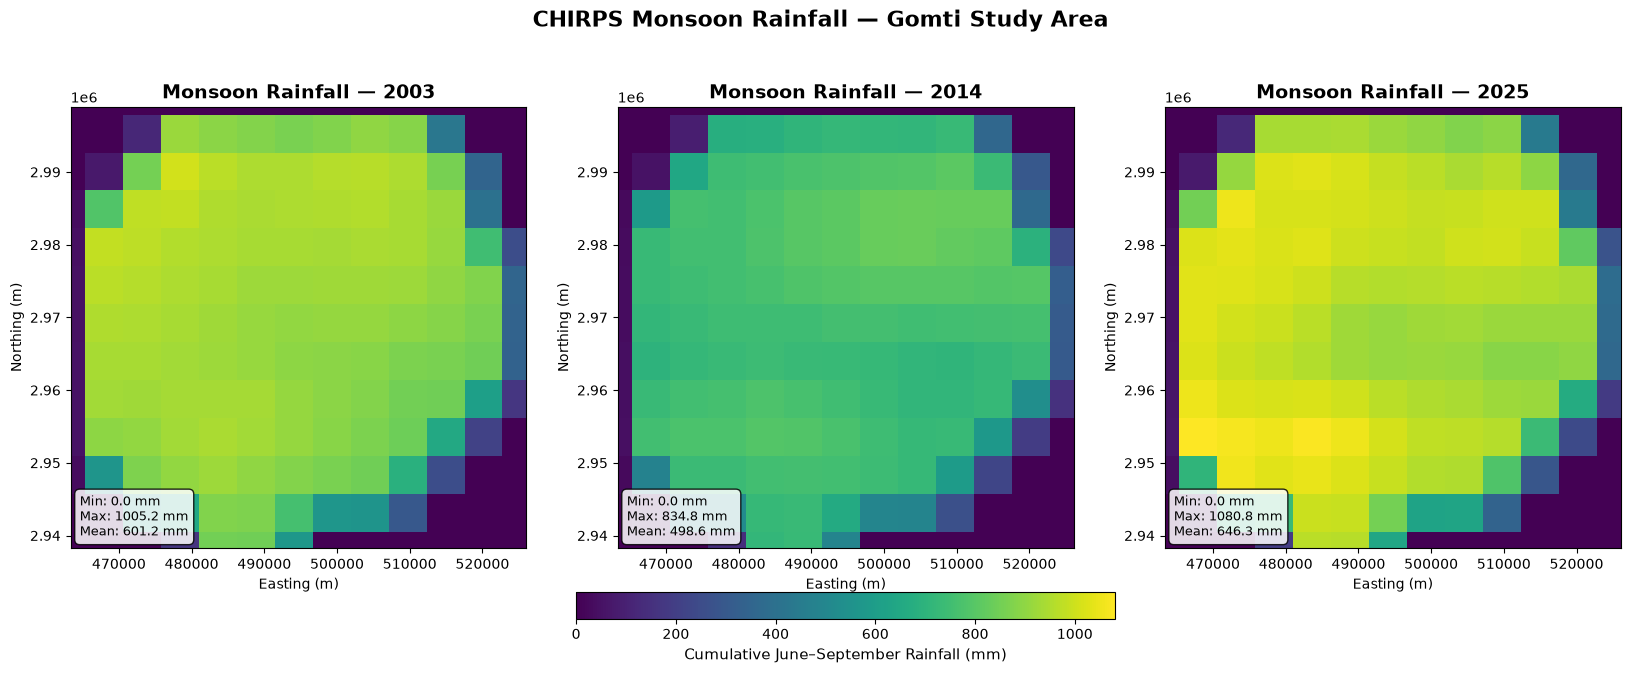


✓ Figure saved:
d:\Projects\GeoAI-Flood-Susceptibility\outputs\figures\notebook_05\CHIRPS_monsoon_rainfall_QA_2003_2014_2025.png


In [16]:
# ============================================================
# Step 05.14 — Monsoon Rainfall QA and Visualization
# ============================================================

from matplotlib.colors import Normalize

# ------------------------------------------------------------
# Notebook 05 figure directory
# ------------------------------------------------------------

NB05_FIGURES_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "notebook_05"
)

NB05_FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# Final rainfall raster paths
# ------------------------------------------------------------

monsoon_rainfall_paths = {
    year: (
        RAINFALL_PROCESSED_DIR
        / str(year)
        / f"CHIRPS_monsoon_rainfall_{year}.tif"
    )
    for year in chirps_years
}

# ------------------------------------------------------------
# QA
# ------------------------------------------------------------

print("=" * 70)
print("NOTEBOOK 05 — MONSOON RAINFALL QA")
print("=" * 70)

reference = None
rainfall_stats = {}

for year in chirps_years:

    path = monsoon_rainfall_paths[year]

    if not path.exists():
        raise FileNotFoundError(
            f"Monsoon rainfall raster not found:\n{path}"
        )

    with rasterio.open(path) as src:

        data = src.read(1)

        finite = data[
            np.isfinite(data)
        ]

        if len(finite) == 0:
            raise ValueError(
                f"No finite rainfall values found:\n{path}"
            )

        current = {
            "shape": src.shape,
            "crs": src.crs,
            "transform": src.transform,
            "resolution": src.res,
            "bounds": src.bounds,
            "count": src.count,
            "dtype": src.dtypes[0]
        }

        # ----------------------------------------------------
        # Spatial consistency
        # ----------------------------------------------------

        if reference is None:

            reference = current

        else:

            for key in [
                "shape",
                "crs",
                "transform",
                "resolution",
                "bounds"
            ]:

                if current[key] != reference[key]:

                    raise ValueError(
                        f"Spatial mismatch for {year}: "
                        f"{key}"
                    )

        rainfall_stats[year] = {
            "min_mm": float(finite.min()),
            "max_mm": float(finite.max()),
            "mean_mm": float(finite.mean()),
            "finite_pixels": int(len(finite))
        }

        print("\n" + "-" * 70)
        print(f"YEAR — {year}")
        print("-" * 70)

        print(f"Shape       : {src.shape}")
        print(f"CRS         : {src.crs}")
        print(f"Resolution  : {src.res}")
        print(f"Bounds      : {src.bounds}")
        print(f"Data type   : {src.dtypes[0]}")
        print(f"Min rainfall: {finite.min():.2f} mm")
        print(f"Max rainfall: {finite.max():.2f} mm")
        print(f"Mean rainfall: {finite.mean():.2f} mm")
        print(f"Finite pixels: {len(finite):,}")

print("\n" + "=" * 70)
print("✓ ALL THREE MONSOON RAINFALL RASTERS PASSED SPATIAL QA")
print("=" * 70)

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(20, 7)
)

# ------------------------------------------------------------
# Common color scale
# ------------------------------------------------------------

global_max = max(
    stats["max_mm"]
    for stats in rainfall_stats.values()
)

norm = Normalize(
    vmin=0,
    vmax=global_max
)

study_bounds = study_area_gdf.total_bounds

for ax, year in zip(
    axes,
    chirps_years
):

    path = monsoon_rainfall_paths[year]

    with rasterio.open(path) as src:

        rainfall = src.read(1)

        # Mask non-finite values
        rainfall_display = np.where(
            np.isfinite(rainfall),
            rainfall,
            np.nan
        )

        extent = [
            src.bounds.left,
            src.bounds.right,
            src.bounds.bottom,
            src.bounds.top
        ]

        image = ax.imshow(
            rainfall_display,
            cmap="viridis",
            norm=norm,
            extent=extent,
            interpolation="none"
        )

    # --------------------------------------------------------
    # Study-area extent
    # --------------------------------------------------------

    ax.set_xlim(
        study_bounds[0],
        study_bounds[2]
    )

    ax.set_ylim(
        study_bounds[1],
        study_bounds[3]
    )

    ax.set_title(
        f"Monsoon Rainfall — {year}",
        fontsize=14,
        fontweight="bold"
    )

    ax.set_xlabel(
        "Easting (m)"
    )

    ax.set_ylabel(
        "Northing (m)"
    )

    # --------------------------------------------------------
    # Statistics box
    # --------------------------------------------------------

    stats = rainfall_stats[year]

    text = (
        f"Min: {stats['min_mm']:.1f} mm\n"
        f"Max: {stats['max_mm']:.1f} mm\n"
        f"Mean: {stats['mean_mm']:.1f} mm"
    )

    ax.text(
        0.02,
        0.02,
        text,
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round,pad=0.4",
            facecolor="white",
            alpha=0.85
        )
    )

# ------------------------------------------------------------
# Shared colorbar
# ------------------------------------------------------------

cbar = fig.colorbar(
    image,
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.08
)

cbar.set_label(
    "Cumulative June–September Rainfall (mm)",
    fontsize=11
)

fig.suptitle(
    "CHIRPS Monsoon Rainfall — Gomti Study Area",
    fontsize=16,
    fontweight="bold"
)


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

rainfall_qa_figure = (
    NB05_FIGURES_DIR
    / "CHIRPS_monsoon_rainfall_QA_2003_2014_2025.png"
)

plt.savefig(
    rainfall_qa_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\n✓ Figure saved:")
print(rainfall_qa_figure)